# Insurance Cost Prediction with Linear Regression

This Jupyter Notebook explores the relationship between age and insurance costs using linear regression.  We use the `insurance.csv` dataset to build a model that predicts insurance charges based on a person's age.


In [90]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [92]:
# Import the data
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [94]:
# Display information about the dataframe, including data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


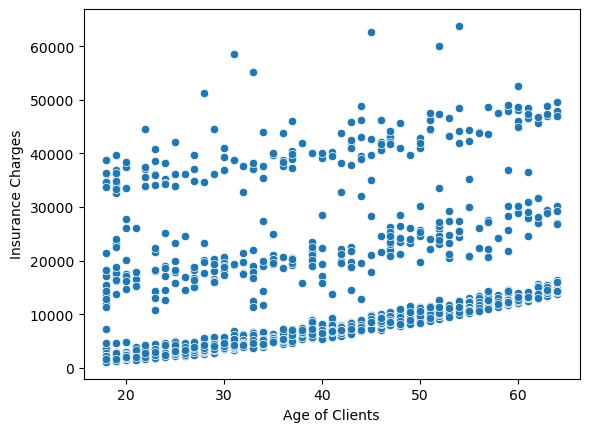

In [96]:
# Create a scatter plot to visualize the relationship between age and charges using seaborn
sns.scatterplot(data=df, x='age', y='charges')
plt.xlabel('Age of Clients')
plt.ylabel('Insurance Charges')
plt.show()

### Data Preparation

We create a new DataFrame df_age_charges containing only the 'age' and 'charges' columns, as these are the variables we'll use for our linear regression model.

In [98]:
# Create a new dataframe containing only the 'age' and 'charges' columns
df_age_charges = df[['age', 'charges']]
df_age_charges.sample(5)

,age,charges
877,33,6653.78860
1037,45,39725.51805
926,19,2913.56900
1235,26,2699.56835
952,30,4527.18295


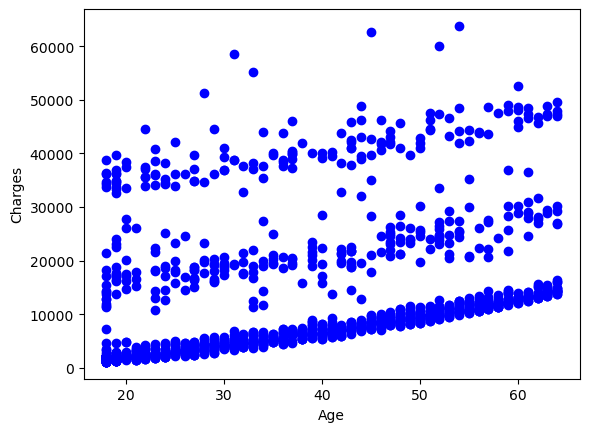

In [100]:
# The iloc function allows us to select rows and columns from the dataframe for plotting.
# This section prepares the data for plotting, separating 'age' (x) and 'charges' (y).
x = df_age_charges.iloc[:,:1].values # Selects all rows and the first column ('age') and converts it to a NumPy array.
y = df_age_charges.iloc[:,-1].values # Selects all rows and the last column ('charges') and converts it to a NumPy array.

# Create a scatter plot of age vs. charges using matplotlib.
plt.scatter(x,y,color = 'b')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

### Linear Regression Model Training and Prediction

We create a LinearRegression object and train it using the prepared data (x and y).  This process finds the best-fit line that minimizes the difference between the predicted and actual charges.

In [102]:
# Reshape x to a 2D array, which is required by sklearn's LinearRegression.
x = df_age_charges.iloc[:, :1].values.reshape(-1, 1)
y = df_age_charges.iloc[:, -1].values

In [104]:
# Fit the linear regression model
model = LinearRegression() # Create a LinearRegression object.
model.fit(x, y) # Train the model using the age (x) and charges (y) data.

# Make predictions using the trained model.
y_pred = model.predict(x)

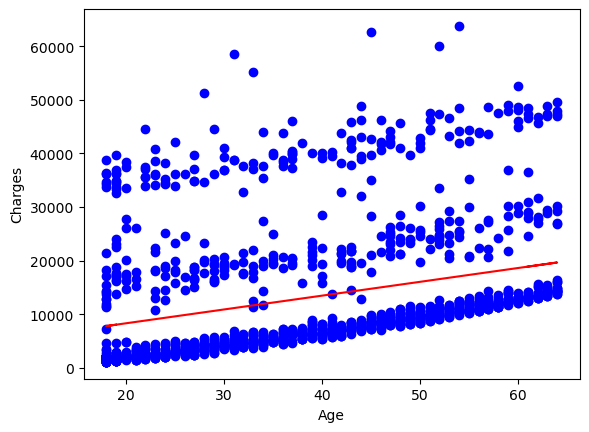

In [106]:
# Plot the original data points and the regression line.
y_pred = model.predict(x) # Predict charges based on age.

plt.scatter(x,y,color = 'b') # Scatter plot of the original data points (age vs. charges).
plt.plot(x,y_pred,color = 'r') # Plot the regression line (predicted charges vs. age).
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

### Visualization of Results

We create a scatter plot of the original data points (age vs. charges) and overlay the best-fit line (predicted charges vs. age).  This allows us to visually assess how well the linear regression model fits the data.

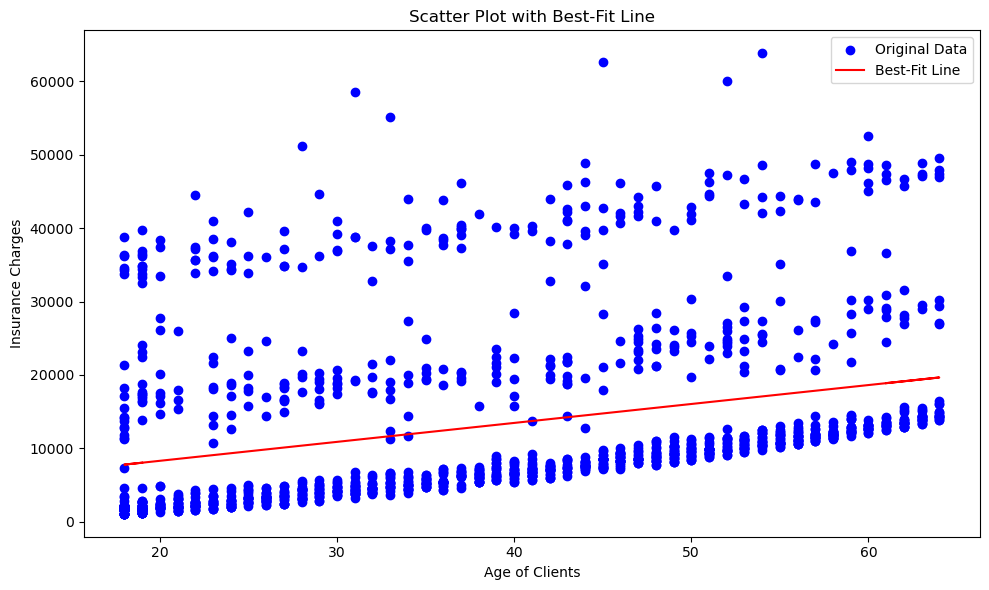

In [110]:
# This section repeats the model fitting and plotting, but uses a slightly different way to access the data.
x = df_age_charges['age'].values.reshape(-1, 1)
y = df_age_charges['charges'].values

model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)

# Create a more visually appealing plot with labels, title, and legend.
plt.figure(figsize=(10, 6)) # Set the figure size.
plt.scatter(x, y, color='b', label='Original Data') # Scatter plot of original data.

plt.plot(x, y_pred, color='r', label='Best-Fit Line') # Plot the regression line.

plt.xlabel('Age of Clients')
plt.ylabel('Insurance Charges')
plt.title('Scatter Plot with Best-Fit Line') # Set the plot title.
plt.xticks()
plt.yticks()
plt.legend() # Show the legend.

plt.tight_layout() # Adjust layout to prevent labels from overlapping.
plt.show()

The plot shows a weak positive correlation between "Age of Clients" and "Insurance Charges".

In essence, while there's a slight tendency for older clients to have higher charges, age only explains a small portion of the variation in insurance costs.  

### Many other variables not included in this analysis likely play a significant role.

## Model Evaluation

Finally, we print the intercept and coefficient of the linear regression model. The intercept represents the estimated insurance charge when age is zero, and the coefficient represents the change in insurance charge for each one-unit increase in age.

In [112]:
# Print the intercept and coefficient of the linear regression model.
print(f"Intercept: {model.intercept_}") # The intercept is the value of y when x is 0.
print(f"Coefficient: {model.coef_[0]}") # The coefficient represents the change in y for a one-unit change in x.

# Calculate and print the R-squared value, which measures the goodness of fit of the model.
from sklearn.metrics import r2_score
r_squared = r2_score(y, y_pred) # Calculate R-squared.
print(f"R-squared: {r_squared}") # Print the R-squared value.

Intercept: 3165.8850060630302
Coefficient: 257.7226186668954
R-squared: 0.08940589967885804


While there's a slight positive correlation between age and insurance charges (as indicated by the positive coefficient), age is not a very influential factor in determining the overall cost. The low R-squared value suggests that other variables are much more important in predicting insurance expenses.